# Notebook 01 — Exploratory Data Analysis

**Goal:** Inspect SPY, VIX, and S&P 500 headline data.  
Cover: head, shape, describe, info, dtypes, nulls, unique values, datetime conversion, duration, close price plot, volume plot, moving averages, MinMax normalisation.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import load_spy_data, load_vix_data, load_headlines, \
                      DATA_START, DATA_END, TRAIN_END, VAL_END

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Imports OK')

Imports OK


---
## 1. SPY Price Data

We inspect the SPY daily OHLCV data for basic structure, data quality, and date range. These checks confirm the index is a proper `DatetimeIndex`, there are no missing values, and the dataset spans the intended 2008–2024 window.

In [2]:
spy = load_spy_data()

print('=== head() ===')
display(spy.head())

=== head() ===


,Close,High,Low,Open,Volume
Date,,,,,
2008-01-02,103.495613,104.966684,102.745809,104.638190,204935600
2008-01-03,103.445610,103.895501,102.881470,103.481318,125133300
2008-01-04,100.910538,102.431590,100.624899,102.360175,232330900
2008-01-07,100.824837,101.567504,100.046462,101.267580,234991000
2008-01-08,99.196709,102.045992,98.861077,101.460429,326365700


In [3]:
print('=== shape ===')
print(spy.shape)

=== shape ===
(4278, 5)


In [4]:
print('=== describe() ===')
display(spy.describe())

=== describe() ===


,Close,High,Low,Open,Volume
count,4278.000000,4278.000000,4278.000000,4278.000000,4.278000e+03
mean,225.458901,226.688109,224.053685,225.426764,1.308836e+08
std,134.322382,134.943722,133.597288,134.304551,9.368599e+07
min,49.808567,51.190716,49.069951,49.691557,2.027000e+07
25%,105.326614,105.804496,104.658673,105.217042,6.942988e+07
50%,179.193672,179.992557,178.726692,179.005718,1.003703e+08
75%,313.986748,316.602505,311.610383,315.055887,1.607806e+08
max,597.109375,598.347202,596.333305,596.991441,8.710263e+08


In [5]:
print('=== info() ===')
spy.info()

=== info() ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4278 entries, 2008-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4278 non-null   float64
 1   High    4278 non-null   float64
 2   Low     4278 non-null   float64
 3   Open    4278 non-null   float64
 4   Volume  4278 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 200.5 KB


In [6]:
print('=== dtypes ===')
print(spy.dtypes)

=== dtypes ===
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [7]:
print('=== null / NaN values ===')
print(spy.isnull().sum())

=== null / NaN values ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
print('=== unique values per column ===')
print(spy.nunique())

=== unique values per column ===
Close     4186
High      4275
Low       4278
Open      4278
Volume    4276
dtype: int64


In [9]:
# pd.to_datetime — confirm DatetimeIndex (already applied by load_spy_data via parse_dates=True)
print('=== index dtype (DatetimeIndex check) ===')
print(type(spy.index), spy.index.dtype)

spy.index = pd.to_datetime(spy.index)
print('After pd.to_datetime:', spy.index.dtype)

=== index dtype (DatetimeIndex check) ===
<class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns]
After pd.to_datetime: datetime64[ns]


In [10]:
# Duration of dataset
print('Starting date: ', spy.index[0])
print('Ending date:   ', spy.index[-1])
print('Duration:      ', spy.index[-1] - spy.index[0])

Starting date:  2008-01-02 00:00:00
Ending date:    2024-12-30 00:00:00
Duration:       6207 days 00:00:00


### 1a. SPY Closing Price & Log Returns

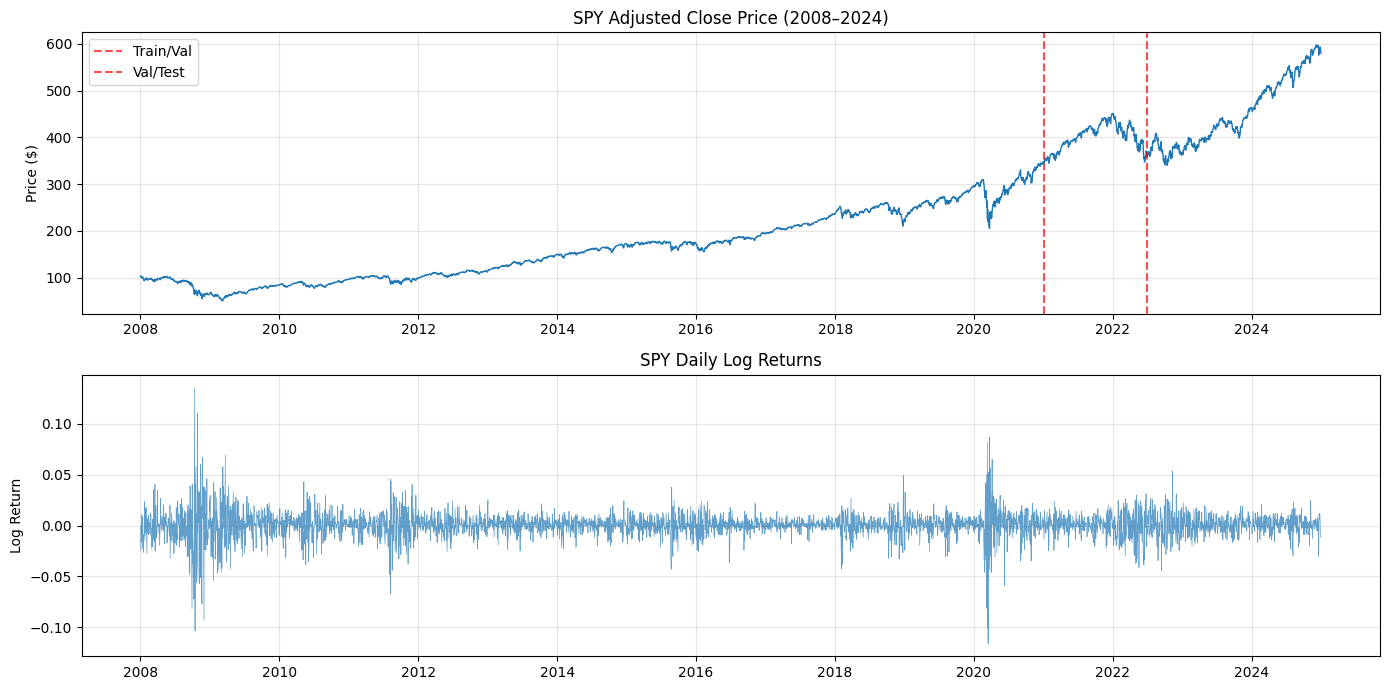

In [11]:
spy['log_return'] = np.log(spy['Close'] / spy['Close'].shift(1))

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(spy.index, spy['Close'], lw=1)
axes[0].set_title('SPY Adjusted Close Price (2008–2024)')
axes[0].set_ylabel('Price ($)')
for split_date, label in [(TRAIN_END, 'Train/Val'), (VAL_END, 'Val/Test')]:
    axes[0].axvline(pd.Timestamp(split_date), color='red', linestyle='--', alpha=0.7, label=label)
axes[0].legend()

axes[1].plot(spy.index, spy['log_return'], lw=0.5, alpha=0.7)
axes[1].set_title('SPY Daily Log Returns')
axes[1].set_ylabel('Log Return')

plt.tight_layout()
plt.show()

### 1b. SPY Volume Plot

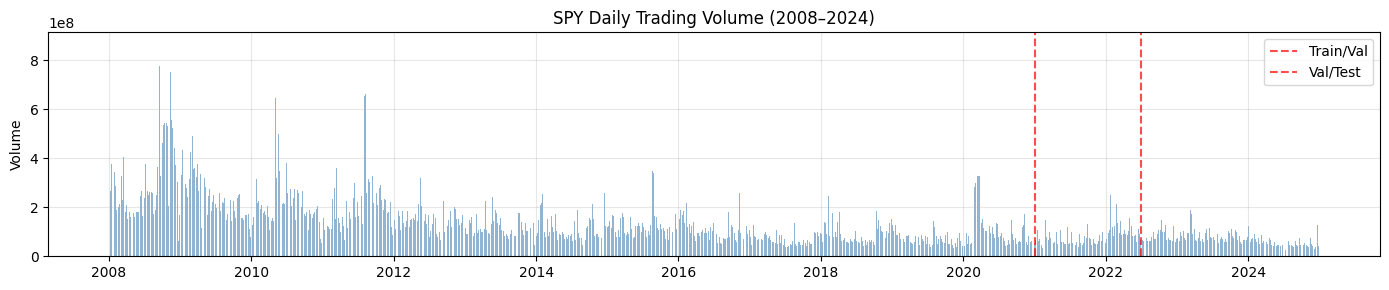

In [12]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(spy.index, spy['Volume'], width=1, alpha=0.6, color='steelblue')
ax.set_title('SPY Daily Trading Volume (2008–2024)')
ax.set_ylabel('Volume')
for split_date, label in [(TRAIN_END, 'Train/Val'), (VAL_END, 'Val/Test')]:
    ax.axvline(pd.Timestamp(split_date), color='red', linestyle='--', alpha=0.7, label=label)
ax.legend()
plt.tight_layout()
plt.show()

### 1c. Target Distribution (Next-Day Direction)

Target class distribution (all data):
target
Up (1)      0.550257
Down (0)    0.449743
Name: proportion, dtype: float64


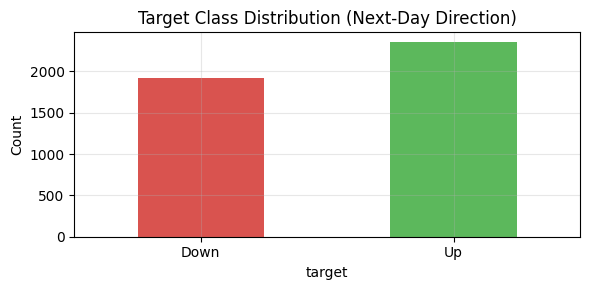

In [13]:
spy['next_return'] = spy['log_return'].shift(-1)
spy['target'] = (spy['next_return'] > 0).astype(int)

print('Target class distribution (all data):')
print(spy['target'].value_counts(normalize=True).rename({0: 'Down (0)', 1: 'Up (1)'}))

fig, ax = plt.subplots(figsize=(6, 3))
spy['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#d9534f', '#5cb85c'])
ax.set_xticklabels(['Down', 'Up'], rotation=0)
ax.set_title('Target Class Distribution (Next-Day Direction)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 1d. SPY Moving Averages

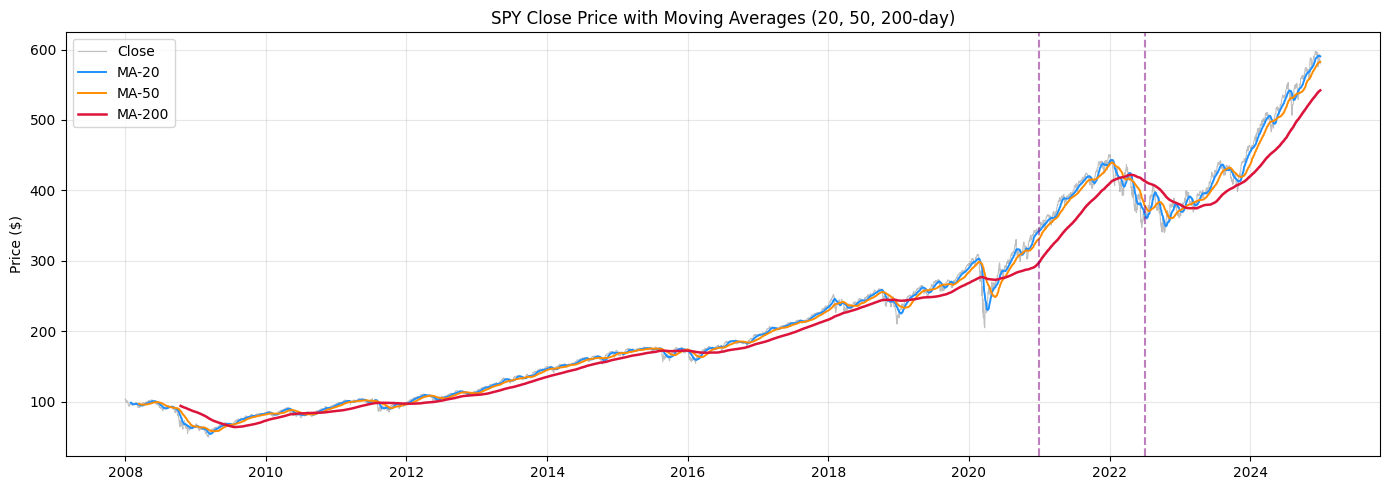

In [14]:
spy['MA_20']  = spy['Close'].rolling(window=20).mean()
spy['MA_50']  = spy['Close'].rolling(window=50).mean()
spy['MA_200'] = spy['Close'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spy.index, spy['Close'],  lw=0.8, alpha=0.5, color='gray',    label='Close')
ax.plot(spy.index, spy['MA_20'],  lw=1.4, color='dodgerblue',          label='MA-20')
ax.plot(spy.index, spy['MA_50'],  lw=1.4, color='darkorange',          label='MA-50')
ax.plot(spy.index, spy['MA_200'], lw=1.8, color='crimson',             label='MA-200')
for split_date in [TRAIN_END, VAL_END]:
    ax.axvline(pd.Timestamp(split_date), color='purple', linestyle='--', alpha=0.5)
ax.set_title('SPY Close Price with Moving Averages (20, 50, 200-day)')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. VIX Data

We repeat the same inspection for VIX (the CBOE Volatility Index). VIX is a key input feature — it measures market fear and tends to spike during corrections. `Volume` is always 0 for VIX (it is an index, not a traded asset), which we confirm here.

In [15]:
vix = load_vix_data()

print('=== head() ===')
display(vix.head())

=== head() ===


,Close,High,Low,Open,Volume
Date,,,,,
2008-01-02,23.170000,24.049999,22.400000,22.580000,0
2008-01-03,22.490000,23.270000,22.110001,23.110001,0
2008-01-04,23.940001,24.299999,23.250000,23.500000,0
2008-01-07,23.790001,24.879999,23.299999,24.620001,0
2008-01-08,25.430000,25.600000,22.629999,23.270000,0


In [16]:
print('=== shape ===')
print(vix.shape)

=== shape ===
(4278, 5)


In [17]:
print('=== describe() ===')
display(vix.describe())

=== describe() ===


,Close,High,Low,Open,Volume
count,4278.000000,4278.000000,4278.000000,4278.000000,4278.0
mean,19.995234,21.180192,19.125947,20.140954,0.0
std,9.111997,9.863426,8.440375,9.159713,0.0
min,9.140000,9.310000,8.560000,9.010000,0.0
25%,13.920000,14.630000,13.490000,14.040000,0.0
50%,17.540001,18.425000,16.790001,17.625000,0.0
75%,23.027501,24.307499,22.090000,23.139999,0.0
max,82.690002,89.529999,72.760002,82.690002,0.0


In [18]:
print('=== info() ===')
vix.info()

=== info() ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4278 entries, 2008-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4278 non-null   float64
 1   High    4278 non-null   float64
 2   Low     4278 non-null   float64
 3   Open    4278 non-null   float64
 4   Volume  4278 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 200.5 KB


In [19]:
print('=== dtypes ===')
print(vix.dtypes)

=== dtypes ===
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [20]:
print('=== null / NaN values ===')
print(vix.isnull().sum())

=== null / NaN values ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [21]:
print('=== unique values per column ===')
print(vix.nunique())

=== unique values per column ===
Close     1984
High      2038
Low       1910
Open      1965
Volume       1
dtype: int64


In [22]:
# Confirm DatetimeIndex
print('=== index dtype (DatetimeIndex check) ===')
print(type(vix.index), vix.index.dtype)
vix.index = pd.to_datetime(vix.index)
print('After pd.to_datetime:', vix.index.dtype)

=== index dtype (DatetimeIndex check) ===
<class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns]
After pd.to_datetime: datetime64[ns]


In [23]:
# Duration of dataset
print('Starting date: ', vix.index[0])
print('Ending date:   ', vix.index[-1])
print('Duration:      ', vix.index[-1] - vix.index[0])

Starting date:  2008-01-02 00:00:00
Ending date:    2024-12-30 00:00:00
Duration:       6207 days 00:00:00


### 2a. VIX Closing Price Plot

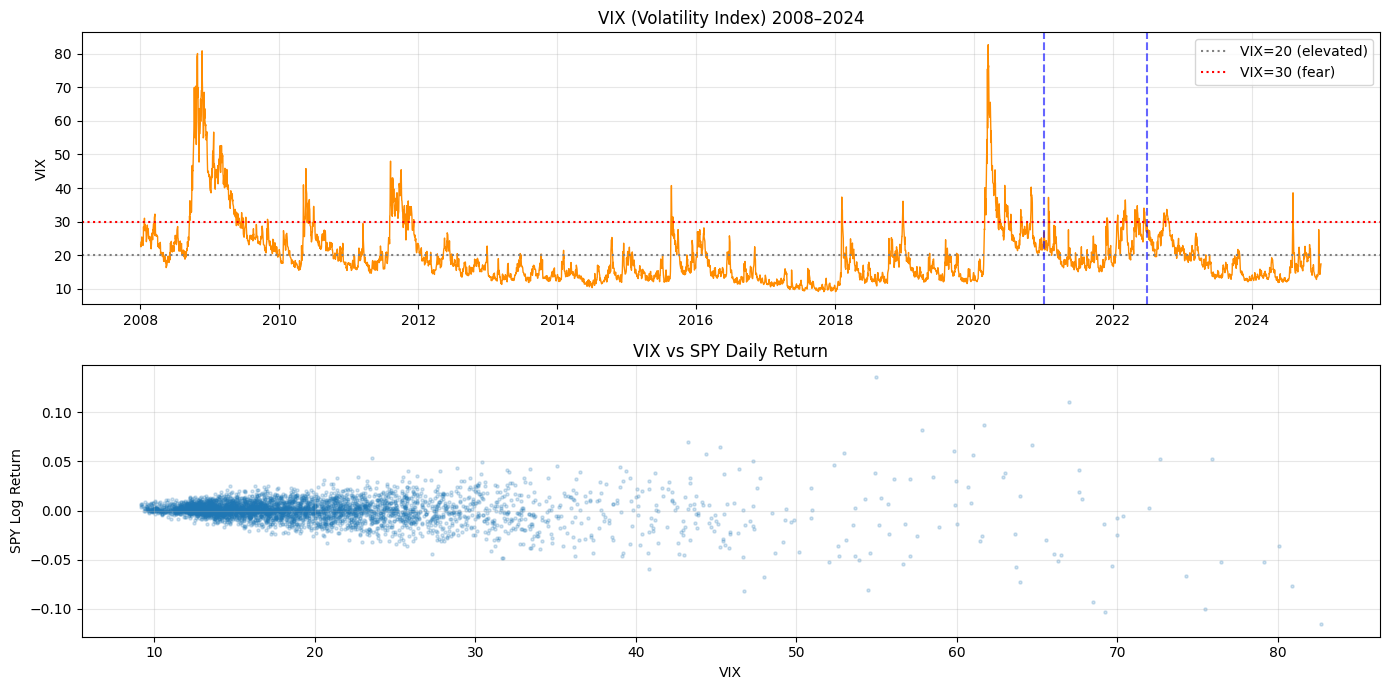

Pearson correlation (VIX vs SPY return): -0.1529


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(vix.index, vix['Close'], lw=1, color='darkorange')
axes[0].axhline(20, color='gray', linestyle=':', label='VIX=20 (elevated)')
axes[0].axhline(30, color='red',  linestyle=':', label='VIX=30 (fear)')
for split_date, label in [(TRAIN_END, 'Train/Val'), (VAL_END, 'Val/Test')]:
    axes[0].axvline(pd.Timestamp(split_date), color='blue', linestyle='--', alpha=0.6)
axes[0].set_title('VIX (Volatility Index) 2008–2024')
axes[0].set_ylabel('VIX')
axes[0].legend()

merged = spy[['log_return']].join(vix[['Close']].rename(columns={'Close': 'vix'}))
axes[1].scatter(merged['vix'], merged['log_return'], alpha=0.2, s=5)
axes[1].set_xlabel('VIX')
axes[1].set_ylabel('SPY Log Return')
axes[1].set_title('VIX vs SPY Daily Return')

plt.tight_layout()
plt.show()

corr = merged['vix'].corr(merged['log_return'])
print(f'Pearson correlation (VIX vs SPY return): {corr:.4f}')

### 2b. VIX Moving Averages

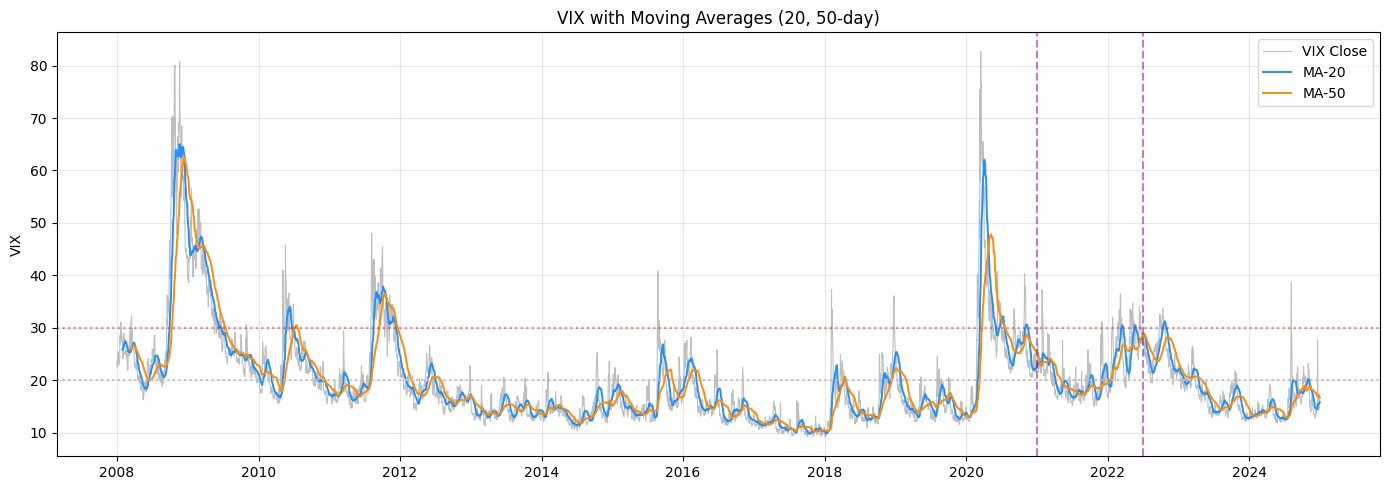

In [25]:
vix['MA_20'] = vix['Close'].rolling(window=20).mean()
vix['MA_50'] = vix['Close'].rolling(window=50).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vix.index, vix['Close'],  lw=0.8, alpha=0.5, color='gray',    label='VIX Close')
ax.plot(vix.index, vix['MA_20'],  lw=1.4, color='dodgerblue',          label='MA-20')
ax.plot(vix.index, vix['MA_50'],  lw=1.4, color='darkorange',          label='MA-50')
ax.axhline(20, color='silver', linestyle=':')
ax.axhline(30, color='red',    linestyle=':', alpha=0.5)
for split_date in [TRAIN_END, VAL_END]:
    ax.axvline(pd.Timestamp(split_date), color='purple', linestyle='--', alpha=0.5)
ax.set_title('VIX with Moving Averages (20, 50-day)')
ax.set_ylabel('VIX')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Headlines Dataset

We inspect the Kaggle S&P 500 headlines CSV. Key things to check: column names, date range (coverage ends 2024-03-04 — not full 2024), null counts, and number of unique headlines per day. The `cp` column is the S&P 500 close price at the time — we only use `title` and `date`.

In [26]:
headlines = load_headlines()

print('=== head() ===')
display(headlines.head())

=== head() ===


,title,date,cp
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


In [27]:
print('=== shape ===')
print(headlines.shape)

=== shape ===
(19127, 3)


In [28]:
print('=== describe() ===')
display(headlines.describe(include='all'))

=== describe() ===


,title,date,cp
count,19127,19127,19127.000000
unique,18054,NaN,NaN
top,What Happened in the Stock Market Today,NaN,NaN
freq,9,NaN,NaN
mean,NaN,2019-09-05 02:15:58.017462016,3262.263384
min,NaN,2008-01-02 00:00:00,676.530000
25%,NaN,2016-09-21 12:00:00,2166.580000
50%,NaN,2020-09-30 00:00:00,3426.920000
75%,NaN,2023-03-14 00:00:00,4288.050000
max,NaN,2024-03-04 00:00:00,5137.080000


In [29]:
print('=== info() ===')
headlines.info()

=== info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19127 entries, 0 to 19126
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   title   19127 non-null  object        
 1   date    19127 non-null  datetime64[ns]
 2   cp      19127 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 448.4+ KB


In [30]:
print('=== dtypes ===')
print(headlines.dtypes)

=== dtypes ===
title            object
date     datetime64[ns]
cp              float64
dtype: object


In [31]:
print('=== null / NaN values ===')
print(headlines.isnull().sum())

=== null / NaN values ===
title    0
date     0
cp       0
dtype: int64


In [32]:
print('=== unique values per column ===')
print(headlines.nunique())

=== unique values per column ===
title    18054
date      3507
cp        3491
dtype: int64


In [33]:
# pd.to_datetime — already applied in load_headlines(); confirm here
print('=== date column dtype (should be datetime64) ===')
print(headlines['date'].dtype)
headlines['date'] = pd.to_datetime(headlines['date'])
print('After pd.to_datetime:', headlines['date'].dtype)

=== date column dtype (should be datetime64) ===
datetime64[ns]
After pd.to_datetime: datetime64[ns]


In [34]:
# Duration of dataset
print('Starting date: ', headlines.iloc[0]['date'])
print('Ending date:   ', headlines.iloc[-1]['date'])
print('Duration:      ', headlines.iloc[-1]['date'] - headlines.iloc[0]['date'])

Starting date:  2008-01-02 00:00:00
Ending date:    2024-03-04 00:00:00
Duration:       5906 days 00:00:00


### 3a. Headline Coverage Analysis

Not every trading day has headlines. We quantify coverage: how many of the 4,174 trading days (2008–2024) have at least one headline, how many per day on average, and how coverage improves over time. Days with no headlines will later be zero-imputed in the embedding stage.

In [35]:
daily_counts = headlines.groupby('date').size().rename('n_headlines')
print(f'Total unique dates with headlines: {len(daily_counts)}')
print(f'Headlines per day — mean: {daily_counts.mean():.1f}, median: {daily_counts.median():.0f}, max: {daily_counts.max()}')
display(daily_counts.describe())

Total unique dates with headlines: 3507
Headlines per day — mean: 5.5, median: 4, max: 55


count    3507.000000
mean        5.453949
std         5.573481
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        55.000000
Name: n_headlines, dtype: float64

In [36]:
trading_days = pd.bdate_range(start=DATA_START, end=DATA_END)
headline_dates_d    = set(d.date() for d in daily_counts.index)
trading_day_dates_d = set(d.date() for d in trading_days)

covered              = headline_dates_d & trading_day_dates_d
missing_trading_days = trading_day_dates_d - headline_dates_d

print(f'Trading days 2008–2024:          {len(trading_day_dates_d)}')
print(f'Trading days WITH headlines:     {len(covered)} ({100*len(covered)/len(trading_day_dates_d):.1f}%)')
print(f'Trading days WITHOUT headlines:  {len(missing_trading_days)}')

Trading days 2008–2024:          4174
Trading days WITH headlines:     3464 (83.0%)
Trading days WITHOUT headlines:  710


In [37]:
# Find all trading days without headlines
trading_days = pd.bdate_range(start="2008-01-01", end="2024-12-31")
headline_dates = set(headlines['date'].dt.date)

missing_days = sorted([d.date() for d in trading_days if d.date() not in headline_dates])
missing_df = pd.DataFrame({'date': missing_days})
missing_df['date'] = pd.to_datetime(missing_df['date'])
missing_df['year'] = missing_df['date'].dt.year

print(f"Total missing: {len(missing_df)}")
print()
print("Missing days by year:")
print(missing_df.groupby('year').size().to_string())

Total missing: 929

Missing days by year:
year
2008    156
2009    171
2010    129
2011     44
2012     20
2013     20
2014     19
2015     18
2016     21
2017     32
2018     18
2019     13
2020     13
2021     11
2022      9
2023     16
2024    219


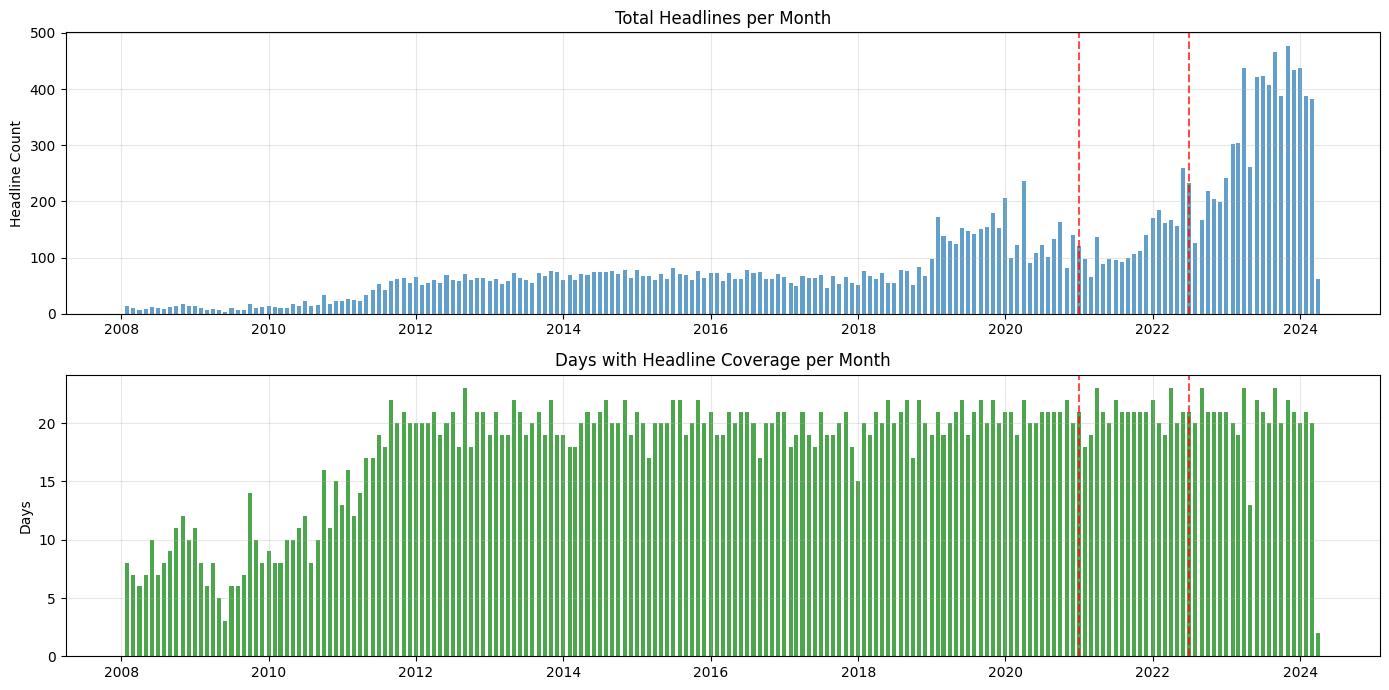

In [38]:
daily_counts_ts = daily_counts.copy()
daily_counts_ts.index = pd.to_datetime(daily_counts_ts.index)
monthly = daily_counts_ts.resample('ME').agg(['sum', 'count'])
monthly.columns = ['total_headlines', 'days_with_coverage']

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].bar(monthly.index, monthly['total_headlines'],    width=20, alpha=0.7)
axes[0].set_title('Total Headlines per Month')
axes[0].set_ylabel('Headline Count')
axes[1].bar(monthly.index, monthly['days_with_coverage'], width=20, alpha=0.7, color='green')
axes[1].set_title('Days with Headline Coverage per Month')
axes[1].set_ylabel('Days')
for ax in axes:
    for split_date in [TRAIN_END, VAL_END]:
        ax.axvline(pd.Timestamp(split_date), color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

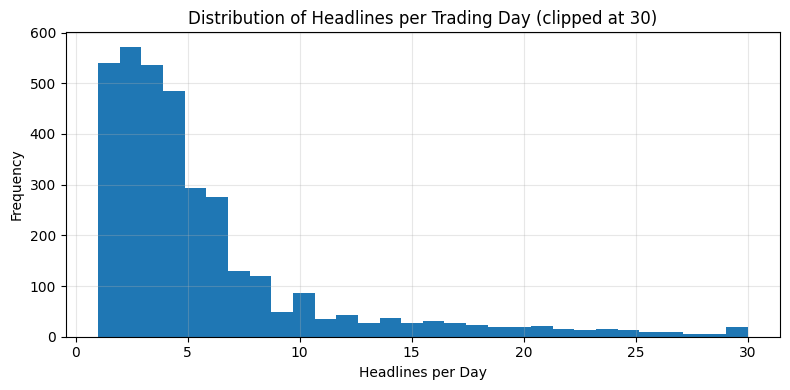

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
daily_counts.clip(upper=30).hist(bins=30, ax=ax)
ax.set_title('Distribution of Headlines per Trading Day (clipped at 30)')
ax.set_xlabel('Headlines per Day')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [40]:
for split_name, start, end in [
    ('Train (2008–2020)', DATA_START, TRAIN_END),
    ('Val   (2021–2022)', TRAIN_END,  VAL_END),
    ('Test  (2023–2024)', VAL_END,    DATA_END),
]:
    mask          = (daily_counts_ts.index >= start) & (daily_counts_ts.index < end)
    split_counts  = daily_counts_ts[mask]
    split_trading = pd.bdate_range(start=start, end=end)
    coverage = 100 * len(split_counts) / len(split_trading)
    print(f"{split_name}: {len(split_counts)} days / {len(split_trading)} trading days = {coverage:.1f}% | avg {split_counts.mean():.1f} headlines/day")

Train (2008–2020): 2719 days / 3394 trading days = 80.1% | avg 3.6 headlines/day
Val   (2021–2022): 374 days / 391 trading days = 95.7% | avg 6.6 headlines/day
Test  (2023–2024): 371 days / 391 trading days = 94.9% | avg 15.9 headlines/day


---
## 4. Summary

| Dataset | Rows | Date Range | Notes |
|---|---|---|---|
| SPY | 4278 | 2008-01-02 → 2024-12-30 | Adjusted close via yfinance |
| VIX | 4278 | 2008-01-02 → 2024-12-30 | ^VIX via yfinance; Volume always 0 |
| Headlines | 19127 | 2008-01-02 → 2024-03-04 | Kaggle sp500_headlines.csv; ~83% trading day coverage (3,464 of 4,174 trading days) |

**Key findings:**
- SPY target is approximately balanced (slightly more up days than down)
- VIX and SPY daily return are negatively correlated (fear → down days)
- Headline coverage gaps will be filled with zero-vectors at the embedding stage